# Progetto Data Science — Customer Churn
## Fase 4-5 — Modellazione, valutazione e interpretazione dei risultati

In questo notebook costruiamo e confrontiamo **tre modelli diversi** per prevedere `Churn`:

1. **Regressione Logistica** — modello lineare
2. **k-Nearest Neighbors (k-NN)** — modello non lineare, basato sulla distanza
3. **Random Forest** — modello non lineare, ensemble di alberi decisionali

A differenza del notebook visto a lezione, qui i dati **non sono già pronti**: dobbiamo noi convertire le variabili categoriche in numeriche e fare lo split train/test.


## 1. Import e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
np.random.seed(42)

df = pd.read_csv('../data/Customer_Churn.csv')

# Stessa pulizia delle fasi precedenti
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset: {df.shape[0]} righe, {df.shape[1]} colonne")


Dataset: 7043 righe, 21 colonne


## 2. Preparazione dei dati per la modellazione

### 2.1 Rimozione delle colonne non utili

Come discusso nella riflessione critica della Fase 2, `customerID` è solo un identificativo univoco, senza valore predittivo: va escluso.


In [2]:
df_model = df.drop(columns=['customerID'])
df_model.shape


(7043, 20)

### 2.2 Codifica della variabile target

`Churn` è testuale (`Yes`/`No`): la trasformiamo in binaria (1 = ha abbandonato, 0 = è rimasto), come richiesto da scikit-learn per la classificazione.


In [3]:
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
df_model['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

### 2.3 Codifica delle variabili categoriche

Il dataset contiene molte colonne testuali con due o più categorie (es. `gender`, `Contract`, `PaymentMethod`, ecc.). I modelli di machine learning richiedono input numerici, quindi:

- le colonne con solo due valori (Yes/No) vengono convertite in 0/1;
- le colonne con più di due categorie vengono trasformate con **one-hot encoding** (`pd.get_dummies`), creando una colonna binaria per ciascuna categoria.


In [4]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# gender è binario ma non Yes/No
df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# Colonne multi-categoria: one-hot encoding
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print(f"Dopo l'encoding: {df_model.shape[1]} colonne")
df_model.head(3)


Dopo l'encoding: 31 colonne


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


### 2.4 Separazione feature (X) e target (y), e train/test split

Usiamo `stratify=y` per mantenere la stessa proporzione di churn nel training set e nel test set (importante viste le classi sbilanciate).


In [5]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Proporzione di churn nel training set:", round(y_train.mean(), 3))
print("Proporzione di churn nel test set:", round(y_test.mean(), 3))


Training set: (5282, 30)
Test set: (1761, 30)

Proporzione di churn nel training set: 0.265
Proporzione di churn nel test set: 0.265


### 2.5 Standardizzazione

Come visto a lezione, la standardizzazione è importante per modelli basati sulla distanza (k-NN) e utile anche per la regressione logistica (aiuta l'ottimizzazione e rende i coefficienti confrontabili). Non è necessaria per la Random Forest.

`fit_transform` si applica solo al training set, `transform` al test set, per evitare data leakage.


In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 3. Modello 1 — Regressione Logistica

Modello **lineare**: stima la probabilità di churn come combinazione lineare delle feature (passata attraverso una funzione sigmoide). Usiamo `class_weight='balanced'` per compensare lo squilibrio tra le due classi, dando più peso alla classe minoritaria (`Churn = Yes`) durante l'addestramento.


In [7]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test, pred_log)
print(f"Accuracy Regressione Logistica: {acc_log:.3f}")


Accuracy Regressione Logistica: 0.750


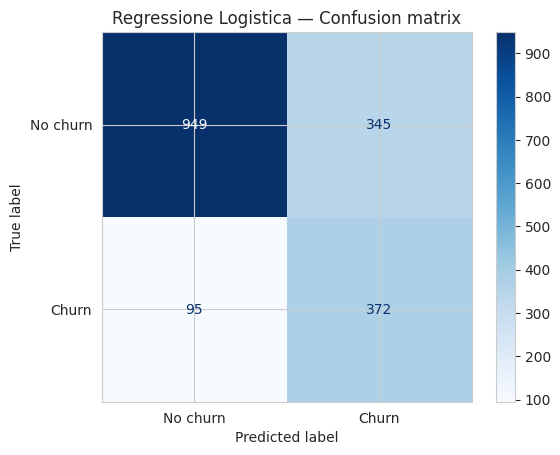

In [8]:
cm_log = confusion_matrix(y_test, pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Regressione Logistica — Confusion matrix')
plt.savefig('../figures/cm_logistic.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
print(classification_report(y_test, pred_log, target_names=['No churn', 'Churn']))


              precision    recall  f1-score   support

    No churn       0.91      0.73      0.81      1294
       Churn       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761



## 4. Modello 2 — k-Nearest Neighbors (k-NN)

Modello **non lineare** basato sulla distanza: classifica un cliente guardando i `k` clienti più simili nel training set. Usiamo k=5, come punto di partenza standard.


In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, pred_knn)
print(f"Accuracy k-NN: {acc_knn:.3f}")


Accuracy k-NN: 0.752


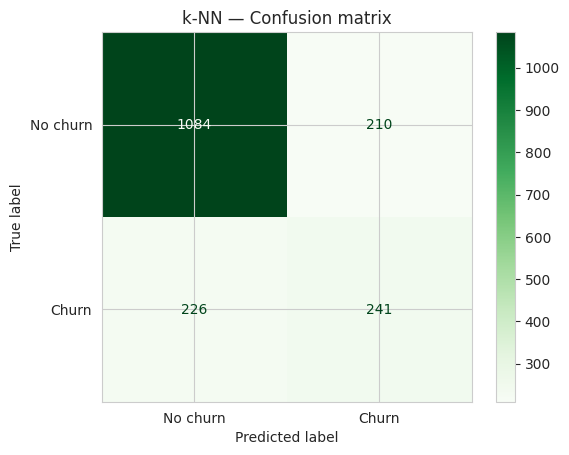

In [11]:
cm_knn = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Greens')
plt.title('k-NN — Confusion matrix')
plt.savefig('../figures/cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
print(classification_report(y_test, pred_knn, target_names=['No churn', 'Churn']))


              precision    recall  f1-score   support

    No churn       0.83      0.84      0.83      1294
       Churn       0.53      0.52      0.53       467

    accuracy                           0.75      1761
   macro avg       0.68      0.68      0.68      1761
weighted avg       0.75      0.75      0.75      1761



**Nota:** a differenza della regressione logistica, k-NN non ha un parametro `class_weight` per gestire lo squilibrio delle classi — è uno dei suoi limiti su questo dataset, e lo si vede infatti nella recall più bassa sulla classe `Churn` rispetto alla regressione logistica.


## 5. Modello 3 — Random Forest

Modello **non lineare**, ensemble di molti alberi decisionali. Non richiede feature standardizzate. Usiamo anche qui `class_weight='balanced'`.


In [13]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.3f}")


Accuracy Random Forest: 0.792


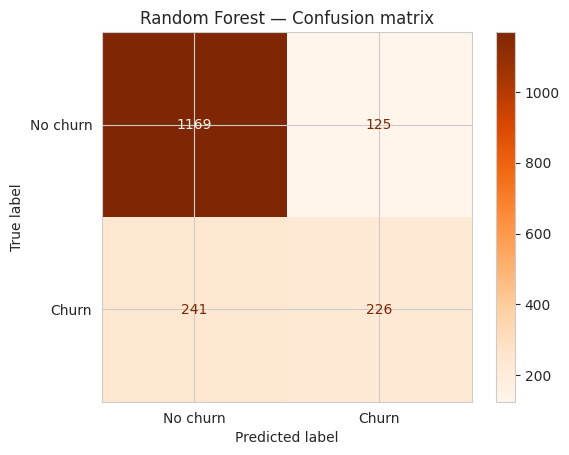

In [14]:
cm_rf = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Oranges')
plt.title('Random Forest — Confusion matrix')
plt.savefig('../figures/cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
print(classification_report(y_test, pred_rf, target_names=['No churn', 'Churn']))


              precision    recall  f1-score   support

    No churn       0.83      0.90      0.86      1294
       Churn       0.64      0.48      0.55       467

    accuracy                           0.79      1761
   macro avg       0.74      0.69      0.71      1761
weighted avg       0.78      0.79      0.78      1761



## 6. Confronto tra i tre modelli


In [16]:
comparison = pd.DataFrame({
    'Modello': ['Regressione Logistica', 'k-NN', 'Random Forest'],
    'Accuracy': [acc_log, acc_knn, acc_rf],
    'Precision (Churn)': [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_rf),
    ],
    'Recall (Churn)': [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_rf),
    ],
    'F1-score (Churn)': [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_rf),
    ],
}).round(3)

comparison


,Modello,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Regressione Logistica,0.750,0.519,0.797,0.628
1,k-NN,0.752,0.534,0.516,0.525
2,Random Forest,0.792,0.644,0.484,0.553


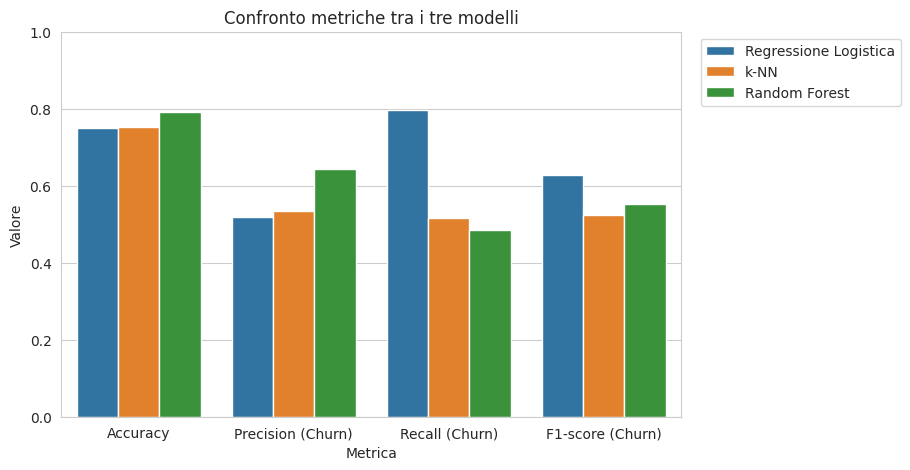

In [17]:
plt.figure(figsize=(8, 5))
comparison_melted = comparison.melt(id_vars='Modello', var_name='Metrica', value_name='Valore')
sns.barplot(data=comparison_melted, x='Metrica', y='Valore', hue='Modello')
plt.title('Confronto metriche tra i tre modelli')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig('../figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretazione del confronto

- **Accuracy**: i tre modelli sono abbastanza vicini, ma è la metrica meno interessante qui: ricordiamo che con il 73.5% di clienti che non abbandonano, un modello che prevede sempre "No" avrebbe già un'accuracy simile senza essere utile.
- **Recall sulla classe Churn** è la metrica più rilevante dal punto di vista pratico: rappresenta quanti dei clienti che davvero abbandonano riusciamo a individuare. Un'azienda userebbe questo modello per contattare i clienti a rischio, quindi mancarne molti (falsi negativi) è il tipo di errore più costoso.
- **k-NN** è penalizzato dall'assenza di gestione dello squilibrio delle classi: recall più bassa sulla classe minoritaria.
- **Regressione Logistica e Random Forest**, entrambe con `class_weight='balanced'`, ottengono recall più alte sulla classe Churn, a scapito della precision (più falsi positivi: clienti segnalati a rischio che in realtà sarebbero rimasti).


## 7. Approfondimento: quali fattori pesano di più?

### 7.1 Feature importance della Random Forest


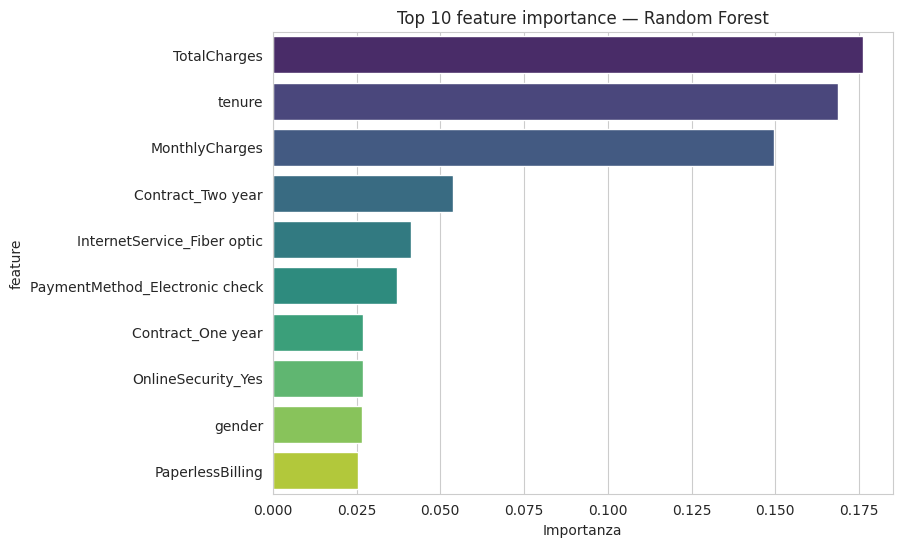

,feature,importance
8,TotalCharges,0.176231
4,tenure,0.168592
7,MonthlyCharges,0.149664
26,Contract_Two year,0.053927
11,InternetService_Fiber optic,0.041338
28,PaymentMethod_Electronic check,0.037031
25,Contract_One year,0.027011
14,OnlineSecurity_Yes,0.026853
0,gender,0.026531
6,PaperlessBilling,0.025547


In [18]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance.head(10), x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 10 feature importance — Random Forest')
plt.xlabel('Importanza')
plt.savefig('../figures/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

importance.head(10)


### 7.2 Coefficienti della Regressione Logistica

Nella regressione logistica, i coefficienti indicano la direzione e la forza dell'effetto di ogni feature (dato che le feature sono standardizzate, sono anche confrontabili tra loro in termini di grandezza). Un coefficiente positivo aumenta la probabilità di churn, uno negativo la diminuisce.


In [19]:
coef = pd.DataFrame({
    'feature': X.columns,
    'coefficiente': log_reg.coef_[0]
}).sort_values('coefficiente', ascending=False)

print("Feature che aumentano di più la probabilità di churn:")
print(coef.head(5))
print()
print("Feature che diminuiscono di più la probabilità di churn:")
print(coef.tail(5))


Feature che aumentano di più la probabilità di churn:
                        feature  coefficiente
11  InternetService_Fiber optic      0.783120
8                  TotalCharges      0.515091
24          StreamingMovies_Yes      0.294727
22              StreamingTV_Yes      0.252022
10            MultipleLines_Yes      0.193337

Feature che diminuiscono di più la probabilità di churn:
               feature  coefficiente
14  OnlineSecurity_Yes     -0.123182
25   Contract_One year     -0.298164
26   Contract_Two year     -0.592687
7       MonthlyCharges     -1.019495
4               tenure     -1.156394


**Interpretazione:** sia la feature importance della Random Forest sia i coefficienti della regressione logistica confermano quanto visto in Fase 3: il tipo di contratto (in particolare avere un contratto a due anni, che riduce fortemente la probabilità di churn) e `tenure` sono tra i fattori più influenti. Questo è rassicurante: due modelli molto diversi tra loro (uno lineare, uno basato su alberi) concordano sui fattori principali, il che rende il risultato più affidabile.

Attenzione: la feature importance e i coefficienti non dimostrano un rapporto di causa-effetto, solo un'associazione statistica appresa dal modello.


## 8. Riflessioni critiche sui risultati

**Punti di forza:** tutti e tre i modelli superano ampiamente un classificatore banale che prevede sempre "No churn" (che avrebbe recall 0 sulla classe di interesse). La regressione logistica e la Random Forest, grazie a `class_weight='balanced'`, riescono a individuare la maggior parte dei clienti a rischio.

**Limiti:**
- Il k-NN è penalizzato dallo squilibrio di classe e dalla dimensionalità (dopo il one-hot encoding abbiamo molte più colonne rispetto al dataset visto a lezione), il che rende le distanze meno informative.
- Nessuno dei modelli raggiunge una precision molto alta sulla classe Churn: significa che, se l'azienda contattasse tutti i clienti segnalati a rischio, molti di questi in realtà sarebbero rimasti comunque (falsi positivi). Va valutato il costo pratico di questo tipo di errore rispetto a quello di non contattare un cliente che invece abbandonerà.

**Interpretabilità:** la regressione logistica è il modello più facile da spiegare (coefficienti diretti), la Random Forest offre comunque la feature importance ma è meno trasparente nel dettaglio, il k-NN è il meno interpretabile dei tre (non ha coefficienti né importanza delle feature).

**Costo computazionale:** la Random Forest con 200 alberi è il modello più lento da addestrare tra i tre, anche se su un dataset di questa dimensione (7043 righe) la differenza è comunque contenuta in pochi secondi.
